In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
result = pd.read_csv("benchmark_result.csv")

# Rename the columns with clearer names
result = result.rename(columns={
    'sense_reversing_barrier_eps_per_ms': 'SRB',
    'sense_reversing_barrier_eps_per_ms_with_eb': 'SRB+EB',
    'pthread_eps_per_ms': 'Pthreads',
    'openmp_eps_per_ms': 'OpenMP'
})

# Aggregate the mean of each time column, grouped by thread count
df = result.groupby('threads')[['SRB', 'SRB+EB', 'Pthreads', 'OpenMP']].mean().reset_index()

df

,threads,SRB,SRB+EB,Pthreads,OpenMP
0,2,2660.688500,2525.258500,198.446150,66.914150
1,4,1181.766000,1126.971900,86.062750,29.092980
2,8,557.555300,650.823600,41.059085,12.399620
3,16,300.442325,381.743045,25.448915,7.724153
4,20,165.311055,259.464850,20.755975,6.919548
5,24,0.897337,0.808878,4.147756,5.561457


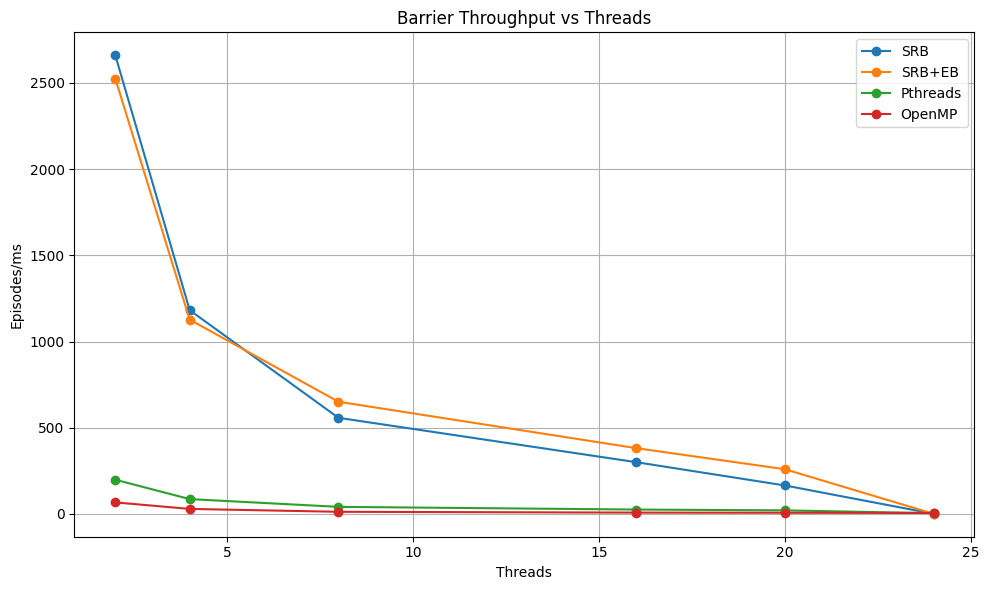

In [3]:
# Rename columns in the DataFrame to use SRB prefixes for sense reversing barrier
df_renamed = df.rename(columns={
    'sense_reversing_barrier_eps_per_ms': 'SRB',
    'sense_reversing_barrier_eps_per_ms_with_eb': 'SRB+EB',
    'pthread_eps_per_ms': 'Pthreads',
    'openmp_eps_per_ms': 'OpenMP'
})

# Draw a line chart for each implementation vs threads
plt.figure(figsize=(10, 6))
for col in [
    'SRB',
    'SRB+EB',
    'Pthreads',
    'OpenMP'
]:
    plt.plot(df_renamed['threads'], df_renamed[col], marker='o', label=col)

plt.xlabel('Threads')
plt.ylabel('Episodes/ms')
plt.title('Barrier Throughput vs Threads')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\Phu Nguyen\AppData\Local\Temp\ipykernel_26392\2424660061.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


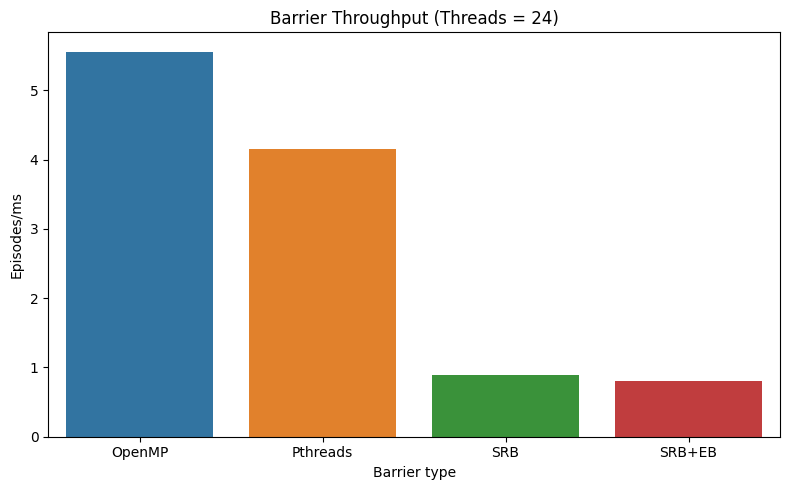

In [4]:
# Filter the DataFrame for threads == 24 and plot sorted vertical bar chart (highest first)
df_24 = df[df['threads'] == 24].melt(id_vars='threads', var_name='Implementation', value_name='Episodes_per_ms')

# Rename implementations for display to match the plotted ones ('SRB', etc.)
impl_map = {
    'sense_reversing_barrier_eps_per_ms': 'SRB',
    'sense_reversing_barrier_eps_per_ms_with_eb': 'SRB+EB',
    'pthread_eps_per_ms': 'Pthreads',
    'openmp_eps_per_ms': 'OpenMP'
}
df_24['Implementation'] = df_24['Implementation'].replace(impl_map)
df_24_sorted = df_24.sort_values(by='Episodes_per_ms', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_24_sorted,
    x='Implementation',
    y='Episodes_per_ms',
    palette='tab10'
)
plt.title('Barrier Throughput (Threads = 24)')
plt.ylabel('Episodes/ms')
plt.xlabel('Barrier type')
plt.tight_layout()
plt.show()